In [1]:
import os
import numpy as np
import glob
from collections import defaultdict
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gsw
from pyproj import Geod
import pandas as pd

# Data Import

In [2]:
def dataconcat (model, scenario, variable): # path of the folder containing the netCDF files 
    dir_path = f"/glade/work/stevenxu/AMOC_models/{variable}/scenarios/{scenario}"
    all_files = glob.glob(os.path.join(dir_path, "*.nc")) 
    
    groups = defaultdict(list) 
    for fp in all_files: 
        fname = os.path.basename(fp) 
        model_name = fname.split("_")[2] 
        groups[model_name].append(fp) 
		
    datasets = {}
    for prefix, files in groups.items(): 
        files = sorted(files) 
        print(f"Concatenating {len(files)} files for {prefix}") 
        ds = xr.open_mfdataset( files, combine="by_coords", parallel=True ) 
        datasets[prefix] = ds.isel(time=slice(-20 * 12, None)) 
    
    return datasets 
              
sst_datasets = dataconcat("ACCESS-ESM1-5", "PIControl", "sea_surface_temperature") 
sss_datasets = dataconcat("ACCESS-ESM1-5", "PIControl", "sea_surface_salinity") 
hf_datasets = dataconcat("ACCESS-ESM1-5", "PIControl", "heatflux") 
wf_datasets = dataconcat("ACCESS-ESM1-5", "PIControl", "waterflux")

Concatenating 12 files for CESM2


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tos' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Concatenating 2 files for ACCESS-ESM1-5


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/coding/times.py:170: SerializationWarning: Ambiguous reference date string: 101-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0101-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/coding/times.py:987: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/core/indexing.py:525: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cft

Concatenating 1 files for ACCESS-CM2


...

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/coding/times.py:170: SerializationWarning: Ambiguous reference date string: 950-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0950-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/coding/times.py:987: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/core/indexing.py:525: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cft

Concatenating 2 files for ACCESS-ESM1-5


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/core/indexing.py:525: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(self.get_duck_array(), dtype=dtype)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/coding/times.py:170: SerializationWarning: Ambiguous reference date string: 101-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0101-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/coding/times.py:987: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects

Concatenating 1 files for ACCESS-CM2


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/coding/times.py:170: SerializationWarning: Ambiguous reference date string: 950-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0950-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/coding/times.py:987: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/core/indexing.py:525: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cft

In [3]:
hf_datasets['ACCESS-ESM1-5']

<xarray.Dataset> Size: 2GB
Dimensions:             (time: 240, bnds: 2, j: 300, i: 360, vertices: 4)
Coordinates:
  * time                (time) object 2kB 0981-01-16 12:00:00 ... 1000-12-16 ...
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude           (j, i) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) object 4kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    vertices_latitude   (time, j, i, vertices) float64 829MB dask.array<chunksize=(240, 300, 360, 2), meta=np.ndarray>
    vertices_longitude  (time, j, i, vertices) float64 829MB dask.array<chunksize=(240, 300, 360, 2), meta=np.ndarray>
    hfds                (time, j, i) float32 104MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36524.0
    creation_date:          2019-11-13T00:24:52Z
    ...                     ...
    variable_id:            hfds
    variant_label:          r1i1p1f1
    version:                v20191112
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/8791656f-ee99-4e12-b36d-c1a0011e5606
    license:                CMIP6 model data produced by CSIRO is licensed un...

In [4]:
sss_datasets['ACCESS-ESM1-5']   ### unit: psu


<xarray.Dataset> Size: 2GB
Dimensions:             (time: 240, bnds: 2, j: 300, i: 360, vertices: 4)
Coordinates:
  * time                (time) object 2kB 0981-01-16 12:00:00 ... 1000-12-16 ...
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude           (j, i) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) object 4kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    vertices_latitude   (time, j, i, vertices) float64 829MB dask.array<chunksize=(240, 300, 360, 2), meta=np.ndarray>
    vertices_longitude  (time, j, i, vertices) float64 829MB dask.array<chunksize=(240, 300, 360, 2), meta=np.ndarray>
    sos                 (time, j, i) float32 104MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36524.0
    creation_date:          2019-11-12T22:34:58Z
    ...                     ...
    variable_id:            sos
    variant_label:          r1i1p1f1
    version:                v20191112
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/fb4c3eae-f0f1-4ede-9e81-68f150d94958
    license:                CMIP6 model data produced by CSIRO is licensed un...

# Calculate sea surface density

In [5]:
def compute_surface_density(model, sst_datasets, sss_datasets, last_n_months=None):
    T  = sst_datasets[model]['tos']          
    SP = sss_datasets[model]['sos']          
    lon = sst_datasets[model]['longitude']
    lat = sst_datasets[model]['latitude']
    # addubg vertices for accurate area-weighted calculations for next step
    vertices_latitude = sst_datasets[model]['vertices_latitude']
    vertices_longitude = sst_datasets[model]['vertices_longitude']

    p0 = 0.0

    if last_n_months is not None:
        T  = T.isel(time=slice(-last_n_months, None))
        SP = SP.isel(time=slice(-last_n_months, None))

    """SA = xr.apply_ufunc(
        gsw.SA_from_SP, SP, p0, lon, lat,
        dask='parallelized', vectorize=True, output_dtypes=[float]
    )
    CT = xr.apply_ufunc(
        gsw.CT_from_t, SA, T, p0,
        dask='parallelized', vectorize=True, output_dtypes=[float]
    )"""
    alpha = xr.apply_ufunc(
        gsw.density.alpha, SP, T, p0,
        dask='parallelized', output_dtypes=[float]
    )
    beta = xr.apply_ufunc(
        gsw.density.beta, SP, T, p0,
        dask='parallelized', output_dtypes=[float]
    )
    rho = xr.apply_ufunc(
        gsw.density.rho, SP, T, p0,
        dask='parallelized', vectorize=True, output_dtypes=[float]
    )

    rho  = rho.rename('rho').assign_attrs(units='kg m-3',  long_name='Sea-surface density')
    alpha  = alpha.rename('alpha')
    beta  = beta.rename('beta')

    return xr.Dataset(dict(rho=rho, alpha=alpha, beta=beta, vertices_latitude=vertices_latitude, vertices_longitude=vertices_longitude))

surf_den_ACCESS = compute_surface_density("ACCESS-ESM1-5", sst_datasets, sss_datasets, last_n_months=240)
surf_den_ACCESS

<xarray.Dataset> Size: 2GB
Dimensions:             (time: 240, j: 300, i: 360, vertices: 4)
Coordinates:
  * time                (time) object 2kB 0981-01-16 12:00:00 ... 1000-12-16 ...
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 864kB -77.88 -77.88 ... 65.63 65.21
    longitude           (j, i) float64 864kB 80.5 81.5 82.5 ... 79.97 79.99
Dimensions without coordinates: vertices
Data variables:
    rho                 (time, j, i) float64 207MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    alpha               (time, j, i) float64 207MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    beta                (time, j, i) float64 207MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    vertices_latitude   (time, j, i, vertices) float64 829MB dask.array<chunksize=(240, 300, 360, 2), meta=np.ndarray>
    vertices_longitude  (time, j, i, vertices) float64 829MB dask.array<chunksize=(240, 300, 360, 2), meta=np.ndarray>

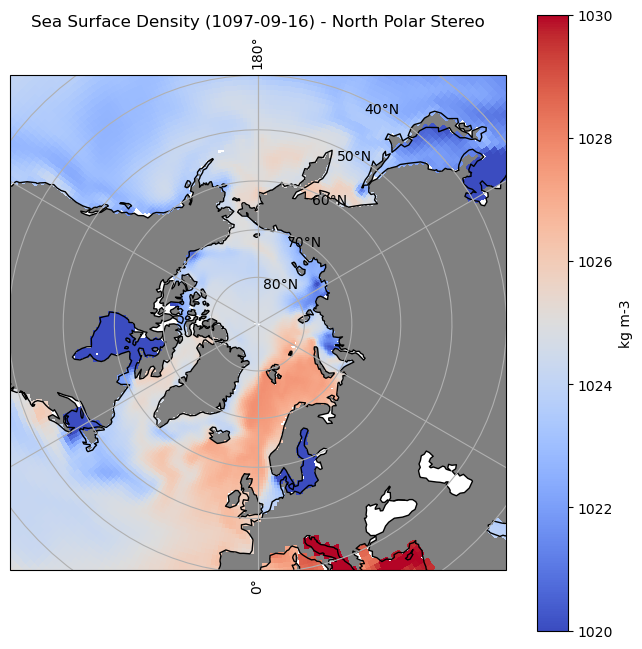

In [22]:
ds = surf_den_ACCESS
da = ds['rho'].isel(time=200)
#da = da.where(da > 1020)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(1, 1, 1, projection=ccrs.NorthPolarStereo())
ax.add_feature(cfeature.LAND, facecolor='gray', zorder=0)

ax.coastlines()
ax.gridlines(draw_labels=True)
ax.set_extent([-180, 180, 40, 90], crs=ccrs.PlateCarree())
pcm = ax.pcolormesh(
    ds['longitude'], ds['latitude'], da,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=1020, 
    vmax=1030  
)
plt.colorbar(pcm, ax=ax, orientation='vertical', label=da.units)
plt.title(f"Sea Surface Density ({str(ds['time'].values[200])[:10]}) - North Polar Stereo")
plt.show()

Average Alpha and Beta

In [6]:
alpha_mean = surf_den_ACCESS["alpha"].mean().compute()
beta_mean  = surf_den_ACCESS["beta"].mean().compute()

print("Overall mean alpha:", float(alpha_mean.values))
print("Overall mean beta:", float(beta_mean.values))

Overall mean alpha: 0.000201614009570031
Overall mean beta: 0.0007457381306028505


# Calculate F surf

In [8]:
def compute_fsurf(model,
                  sst_datasets, sss_datasets, hf_datasets, wf_datasets,
                  cp=3990.0, rho0=1027.0, rho_fw=1000.0, S0=35.0,
                  last_n_months=None):

    HF = hf_datasets[model]['hfds']  # W m^-2, 
    WF = wf_datasets[model]['wfo']     # kg m^-2 s^-1, 
    lon = sst_datasets[model]['longitude']
    lat = sst_datasets[model]['latitude']
    p0 = 0.0

    density_data = compute_surface_density(model, sst_datasets, sss_datasets, last_n_months=last_n_months)
    rho = density_data['rho']
    alpha = density_data['alpha']
    beta = density_data['beta']

    if last_n_months is not None:
        HF  = HF.isel(time=slice(-last_n_months, None))
        WF = WF.isel(time=slice(-last_n_months, None))

    # f_surf = -(alpha/cp) * f_heat  - (rho0/rho_fw) * beta * S0 * f_water
    fsurf = (alpha / cp) * HF  +  (rho0 / rho_fw) * beta * S0 * WF
    fsurf = fsurf.assign_attrs(
        long_name="Buoyancy-relevant surface forcing (Eq. 5)",
        description="(alpha/cp)*f_heat + (rho0/rho_fw)*beta*S0*f_water",
        units="",
        cp=cp, rho0=rho0, rho_fw=rho_fw, S0=S0
    )

    heat_comp = (alpha / cp) * HF
    fw_comp = (rho0 / rho_fw) * beta * S0 * WF

    return xr.Dataset(dict(fsurf=fsurf, rho=rho, heat_comp=heat_comp, fw_comp=fw_comp))

Fsurf_data = compute_fsurf(
    "ACCESS-ESM1-5",
    sst_datasets=sst_datasets,
    sss_datasets=sss_datasets,
    hf_datasets=hf_datasets,
    wf_datasets=wf_datasets,
    last_n_months=240
)

Fsurf_data

<xarray.Dataset> Size: 831MB
Dimensions:    (time: 240, j: 300, i: 360)
Coordinates:
  * time       (time) object 2kB 0981-01-16 12:00:00 ... 1000-12-16 12:00:00
  * j          (j) int32 1kB 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
  * i          (i) int32 1kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 864kB -77.88 -77.88 -77.88 ... 66.04 65.63 65.21
    longitude  (j, i) float64 864kB 80.5 81.5 82.5 83.5 ... 79.96 79.97 79.99
Data variables:
    fsurf      (time, j, i) float64 207MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    rho        (time, j, i) float64 207MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    heat_comp  (time, j, i) float64 207MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    fw_comp    (time, j, i) float64 207MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>

4.50116174204041e-05


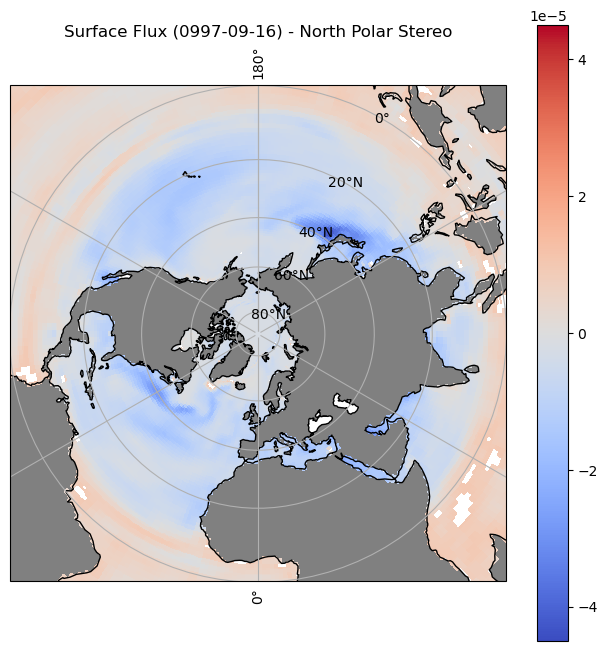

In [15]:
ds = Fsurf_data
da = ds['fsurf'].isel(time=10)
da = da.where(da < 0.00001)  # filter out the abnormal values

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(1, 1, 1, projection=ccrs.NorthPolarStereo())
ax.add_feature(cfeature.LAND, facecolor='gray', zorder=0)

ax.coastlines()
ax.gridlines(draw_labels=True)
ax.set_extent([-180, 180, 0, 30], crs=ccrs.PlateCarree())

v = np.nanmax(np.abs(da.values))
print(v)
pcm = ax.pcolormesh(
    ds['longitude'], ds['latitude'], da,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=-v, vmax=v
)
plt.colorbar(pcm, ax=ax, orientation='vertical', label=da.units)
plt.title(f"Surface Flux ({str(ds['time'].values[200])[:10]}) - North Polar Stereo")
plt.show()

# Calculating Fgen at single timepoint

### Create density class list
Take max and min in rho values, and slice with interval 0.01

In [ ]:
rho_min = 1015
rho_max = 1030

In [ ]:
step_size = 0.05
rho_classes = np.arange(rho_min - step_size, rho_max + step_size, step_size)

### Dataset for area at each grid cell

In [ ]:
dir_path = "/glade/work/stevenxu/AMOC_models/areacello"
all_files = glob.glob(os.path.join(dir_path, "*.nc")) 

area_ds = defaultdict(list)
model_names = []
for fp in all_files: 
    fname = os.path.basename(fp) 
    model_name = fname.split("_")[2] 
    area  = xr.open_dataset(fp)["areacello"]
    model_names.append(model_name)
    area_ds[model_name].append(area)
	

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'areacello' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [ ]:
# Using the ACCEES-CM2 areacello
area  = area_ds[list(area_ds.keys())[1]][0]
area

<xarray.DataArray 'areacello' (j: 300, i: 360)> Size: 432kB
[108000 values with dtype=float32]
Coordinates:
  * j          (j) int32 1kB 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
  * i          (i) int32 1kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 864kB ...
    longitude  (j, i) float64 864kB ...
Attributes:
    standard_name:  cell_area
    long_name:      Grid-Cell Area for Ocean Variables
    comment:        Horizontal area of ocean grid cells
    units:          m2
    cell_methods:   area: sum

### Integration

Group by density intervals and adding up the area-weighted fsurf

In [ ]:
# build mask on 2D fields
mask = (Fsurf_data["latitude"] > 45)

# stack WITH a MultiIndex (default create_index=True)
mask_s   = mask.stack(points=("j","i"))

# keep labels where mask is True (these labels are (j,i) pairs)
keep_pts = mask_s.where(mask_s, drop=True).coords["points"]

# stack data and select by labels (sel, not isel)
fsurf = Fsurf_data["fsurf"].stack(points=("j","i")).sel(points=keep_pts)
heat_comp = Fsurf_data["heat_comp"].stack(points=("j","i")).sel(points=keep_pts)
fw_comp = Fsurf_data["fw_comp"].stack(points=("j","i")).sel(points=keep_pts)
rho   = Fsurf_data["rho"].stack(points=("j","i")).sel(points=keep_pts)
area1 = area.stack(points=("j","i")).sel(points=keep_pts)

# unstack back to (j, i)
weighted_fsurf = (fsurf * area1).unstack("points").values
weighted_heat_comp = (heat_comp * area1).unstack("points").values
weighted_fw_comp = (fw_comp * area1).unstack("points").values
area_comp = area1.unstack("points").values

rho = rho.unstack("points").values

timepoints = Fsurf_data['time'].values

# time: 240  j: 300  i: 360


: 

: 

In [ ]:
Fgen = pd.DataFrame(columns=['time', 'rho', 'Fgen', 'HeatFlux', 'FreshwaterFlux', 'AreaSum'])
total_timepoints = len(timepoints)
timepoints = Fsurf_data['time'].values

for time in range(len(timepoints)):
    for class_idx, rhoclass in enumerate(rho_classes):
        # find range of density
        rhotop = rhoclass + step_size
        rhobot = rhoclass
        # locate density index that are in the range
        rho_idx = np.where((rho[time]>rhobot) & (rho[time]<rhotop))
        inrange_fsurf = []
        inrange_heat_comp = []
        inrange_fw_comp = []
        inrange_area = []
        # looking for all locations that fits the density range
        for lat_idx, lon in enumerate(rho_idx[1]):
            lat = rho_idx[0][lat_idx]
            # adding all valid value into an array
            inrange_fsurf.append(weighted_fsurf[time][lat][lon])
            inrange_heat_comp.append(weighted_heat_comp[time][lat][lon])
            inrange_fw_comp.append(weighted_fw_comp[time][lat][lon])
            inrange_area.append(area_comp[lat][lon])
        # summing up all valid value and process it
        fgen_value = sum(inrange_fsurf) / step_size / 1e6
        heat_comp_value = sum(inrange_heat_comp) / step_size / 1e6
        fw_comp_value = sum(inrange_fw_comp) / step_size / 1e6
        area_sum = sum(inrange_area)
        # outputing
        Fgen.loc[len(Fgen)] = [time, rhoclass + step_size/2, fgen_value, heat_comp_value, fw_comp_value, area_sum]
    print(time+1, "/", total_timepoints, end="\r", flush=True)
Fgen = Fgen.groupby('rho', as_index=False)[['Fgen', 'HeatFlux', 'FreshwaterFlux', 'AreaSum']].mean()

In [ ]:
Fgen_clip = Fgen[(Fgen['rho'] >1020)]
plt.figure(figsize=(8,5))
plt.plot(Fgen_clip['rho'], Fgen_clip['Fgen'],'--', label = 'Fgen',  color='black', linewidth=2)
plt.plot(Fgen_clip['rho'], Fgen_clip['HeatFlux'], label='Heat Flux')
plt.plot(Fgen_clip['rho'], Fgen_clip['FreshwaterFlux'], label='Freshwater Flux')

plt.xlabel('rho')
plt.ylabel('Fgen')
plt.title('Fgen vs Rho')
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

In [ ]:
Fgen_clip = Fgen[(Fgen['rho'] >1020)]
plt.figure(figsize=(8,5))
plt.plot(Fgen_clip['rho'], Fgen_clip['AreaSum'], label = 'Area Sum')

plt.xlabel('rho')
plt.ylabel('Area Sum')
plt.title('Area vs Rho')
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

In [ ]:
import pickle

save_path = "/glade/work/stevenxu/AMOC_models/ACCESS-ESM1-5_Fgen.pkl"
with open(save_path, "wb") as f:
    pickle.dump(Fgen, f)